# Part 1: Q-Learning & Policy Iteration on Frozen Lake

In this notebook we walk through solving the [FrozenLake](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) environment from Gymnasium using two approaches:

1. **Tabular Q-Learning** - a model-free method that learns action-values from experience.
2. **Policy Iteration** - a model-based dynamic programming method that uses the known transition model.

We will also perform a hyperparameter sweep to understand how the learning rate ($\alpha$), discount factor ($\gamma$), and exploration rate ($\epsilon$) affect Q-learning performance.

## 1. Setup and Imports

In [5]:
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

sns.set_theme()

## 2. Parameters

We bundle all hyperparameters into a `NamedTuple` so they are easy to pass around and modify.

In [6]:
class Params(NamedTuple):
    total_episodes: int  # Total episodes
    learning_rate: float  # Learning rate (alpha)
    gamma: float  # Discount factor
    epsilon: float  # Exploration probability
    map_size: int  # Side length of the square grid
    seed: int  # Random seed for reproducibility
    is_slippery: bool  # Stochastic transitions if True
    n_runs: int  # Independent runs (to average over stochasticity)
    action_size: int  # Filled in after env creation
    state_size: int  # Filled in after env creation
    proba_frozen: float  # Probability a tile is frozen (not a hole)


params = Params(
    total_episodes=2000,
    learning_rate=0.8,
    gamma=0.95,
    epsilon=0.1,
    map_size=5,
    seed=123,
    is_slippery=False,
    n_runs=20,
    action_size=None,
    state_size=None,
    proba_frozen=0.9,
)

rng = np.random.default_rng(params.seed)
print(params)

Params(total_episodes=2000, learning_rate=0.8, gamma=0.95, epsilon=0.1, map_size=5, seed=123, is_slippery=False, n_runs=20, action_size=None, state_size=None, proba_frozen=0.9)


## 3. The FrozenLake Environment

FrozenLake is a grid-world where the agent starts at the top-left corner (**S**) and must reach the goal at the bottom-right (**G**) while avoiding holes (**H**). The agent can move in four directions: Left (0), Down (1), Right (2), Up (3).

Let's create a random map and inspect it.

Action size: 4
State size: 25


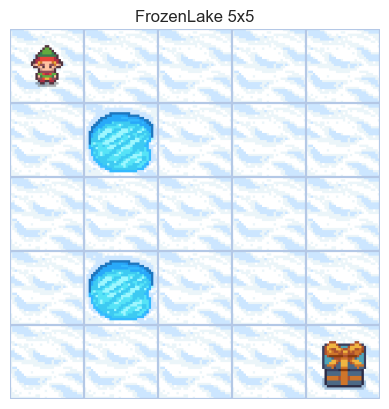

In [7]:
env = gym.make(
    "FrozenLake-v1",
    is_slippery=params.is_slippery,
    render_mode="rgb_array",
    desc=generate_random_map(
        size=params.map_size, p=params.proba_frozen, seed=params.seed
    ),
)

params = params._replace(
    action_size=env.action_space.n,
    state_size=env.observation_space.n,
)
print(f"Action size: {params.action_size}")
print(f"State size: {params.state_size}")

# Show the rendered grid
env.reset()
plt.imshow(env.render())
plt.axis("off")
plt.title(f"FrozenLake {params.map_size}x{params.map_size}")
plt.show()

## 4. Q-Learning Agent & Epsilon-Greedy Exploration

**Q-Learning** updates the Q-table using the Bellman equation:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

The **epsilon-greedy** strategy picks a random action with probability $\epsilon$ (exploration) and the greedy action otherwise (exploitation).

In [8]:
class Qlearning:
    def __init__(self, learning_rate, gamma, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.learning_rate = learning_rate
        self.gamma = gamma
        self.reset_qtable()

    def update(self, state, action, reward, new_state):
        """Update Q(s,a) := Q(s,a) + lr * [R + gamma * max Q(s',a') - Q(s,a)]"""
        delta = (
            reward
            + self.gamma * np.max(self.qtable[new_state, :])
            - self.qtable[state, action]
        )
        q_update = self.qtable[state, action] + self.learning_rate * delta
        return q_update

    def reset_qtable(self):
        """Reset the Q-table to zeros."""
        self.qtable = np.zeros((self.state_size, self.action_size))


class EpsilonGreedy:
    def __init__(self, epsilon, rng):
        self.epsilon = epsilon
        self.rng = rng

    def choose_action(self, action_space, state, qtable):
        """Choose an action using epsilon-greedy."""
        if self.rng.uniform(0, 1) < self.epsilon:
            # Exploration: random action
            action = action_space.sample()
        else:
            # Exploitation: best action (break ties randomly)
            max_ids = np.where(qtable[state, :] == qtable[state, :].max())[0]
            action = self.rng.choice(max_ids)
        return action

## 5. Training Loop

We run the agent for `total_episodes` episodes, repeated over `n_runs` independent runs to smooth out randomness.

In [9]:
def run_env(env, params, learner, explorer):
    """Train the Q-learning agent and return results."""
    rewards = np.zeros((params.total_episodes, params.n_runs))
    steps = np.zeros((params.total_episodes, params.n_runs))
    episodes = np.arange(params.total_episodes)
    qtables = np.zeros((params.n_runs, params.state_size, params.action_size))
    all_states = []
    all_actions = []

    for run in range(params.n_runs):
        learner.reset_qtable()

        for episode in tqdm(
            episodes, desc=f"Run {run}/{params.n_runs} - Episodes", leave=False
        ):
            state = env.reset(seed=params.seed)[0]
            step = 0
            done = False
            total_rewards = 0

            while not done:
                action = explorer.choose_action(
                    action_space=env.action_space, state=state, qtable=learner.qtable
                )
                all_states.append(state)
                all_actions.append(action)

                new_state, reward, terminated, truncated, info = env.step(action)
                done = terminated or truncated

                learner.qtable[state, action] = learner.update(
                    state, action, reward, new_state
                )

                total_rewards += reward
                step += 1
                state = new_state

            rewards[episode, run] = total_rewards
            steps[episode, run] = step
        qtables[run, :, :] = learner.qtable

    return rewards, steps, episodes, qtables, all_states, all_actions

## 6. Visualization Helpers

In [10]:
def postprocess(episodes, params, rewards, steps, map_size):
    """Convert simulation results into dataframes for easy plotting."""
    res = pd.DataFrame(
        data={
            "Episodes": np.tile(episodes, reps=params.n_runs),
            "Rewards": rewards.flatten(order="F"),
            "Steps": steps.flatten(order="F"),
        }
    )
    res["cum_rewards"] = rewards.cumsum(axis=0).flatten(order="F")
    res["map_size"] = np.repeat(f"{map_size}x{map_size}", res.shape[0])

    st = pd.DataFrame(data={"Episodes": episodes, "Steps": steps.mean(axis=1)})
    st["map_size"] = np.repeat(f"{map_size}x{map_size}", st.shape[0])
    return res, st


def qtable_directions_map(qtable, map_size):
    """Get the best learned action & map it to arrows."""
    qtable_val_max = qtable.max(axis=1).reshape(map_size, map_size)
    qtable_best_action = np.argmax(qtable, axis=1).reshape(map_size, map_size)
    directions = {0: "\u2190", 1: "\u2193", 2: "\u2192", 3: "\u2191"}
    qtable_directions = np.empty(qtable_best_action.flatten().shape, dtype=str)
    eps = np.finfo(float).eps
    for idx, val in enumerate(qtable_best_action.flatten()):
        if qtable_val_max.flatten()[idx] > eps:
            qtable_directions[idx] = directions[val]
    qtable_directions = qtable_directions.reshape(map_size, map_size)
    return qtable_val_max, qtable_directions


def plot_q_values_map(qtable, env, map_size):
    """Plot the last frame and learned policy side by side."""
    qtable_val_max, qtable_directions = qtable_directions_map(qtable, map_size)

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    ax[0].imshow(env.render())
    ax[0].axis("off")
    ax[0].set_title("Last frame")

    sns.heatmap(
        qtable_val_max,
        annot=qtable_directions,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title="Learned Q-values\nArrows represent best action")
    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")
    plt.tight_layout()
    plt.show()


def plot_states_actions_distribution(states, actions, map_size):
    """Plot the distributions of visited states and chosen actions."""
    labels = {"LEFT": 0, "DOWN": 1, "RIGHT": 2, "UP": 3}
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    sns.histplot(data=states, ax=ax[0], kde=True)
    ax[0].set_title("States")
    sns.histplot(data=actions, ax=ax[1])
    ax[1].set_xticks(list(labels.values()), labels=labels.keys())
    ax[1].set_title("Actions")
    fig.tight_layout()
    plt.show()


def plot_steps_and_rewards(rewards_df, steps_df):
    """Plot cumulative rewards and average steps."""
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    sns.lineplot(data=rewards_df, x="Episodes", y="cum_rewards", hue="map_size", ax=ax[0])
    ax[0].set(ylabel="Cumulated rewards")
    sns.lineplot(data=steps_df, x="Episodes", y="Steps", hue="map_size", ax=ax[1])
    ax[1].set(ylabel="Averaged steps number")
    for axi in ax:
        axi.legend(title="map size")
    fig.tight_layout()
    plt.show()

## 7. Train Across Multiple Map Sizes

We train Q-learning on 4x4, 7x7, 9x9, and 11x11 maps to see how the agent scales with environment complexity.

Map size: 4x4


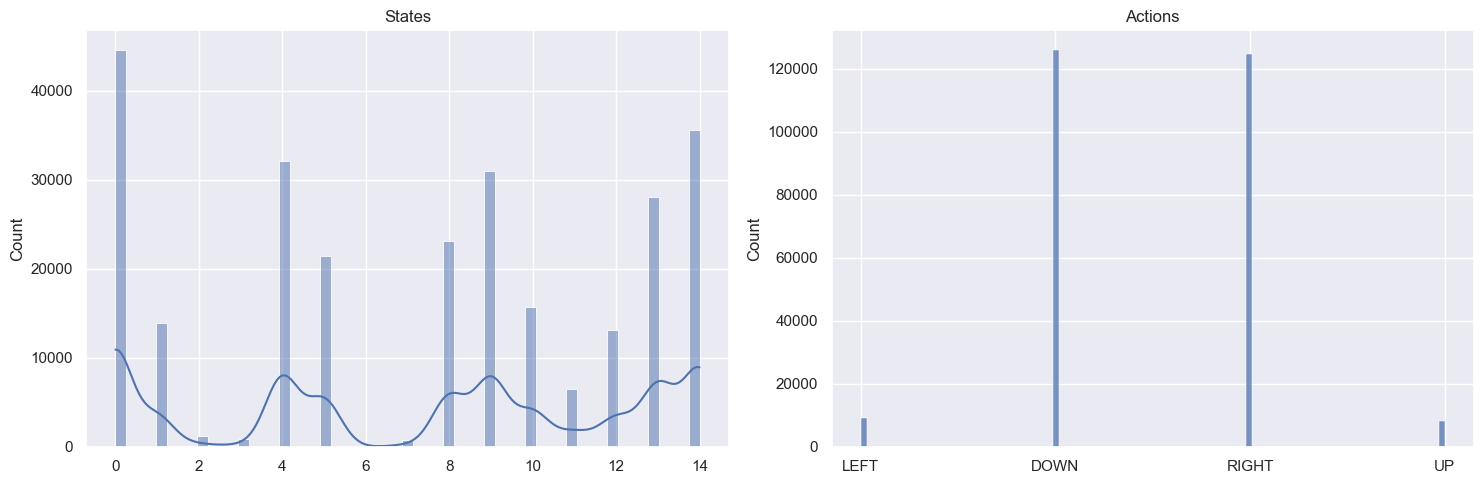

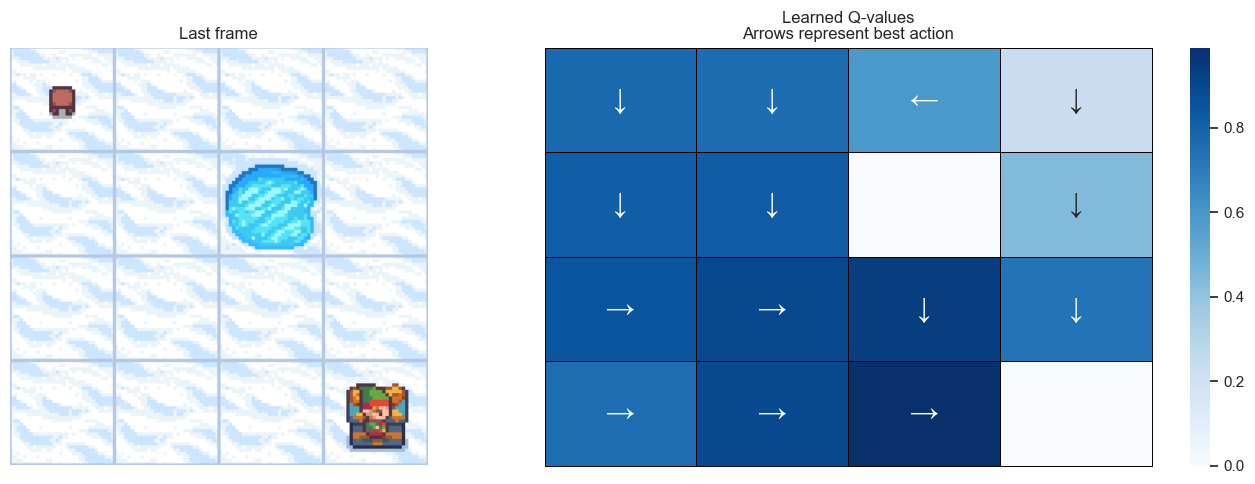

Map size: 7x7


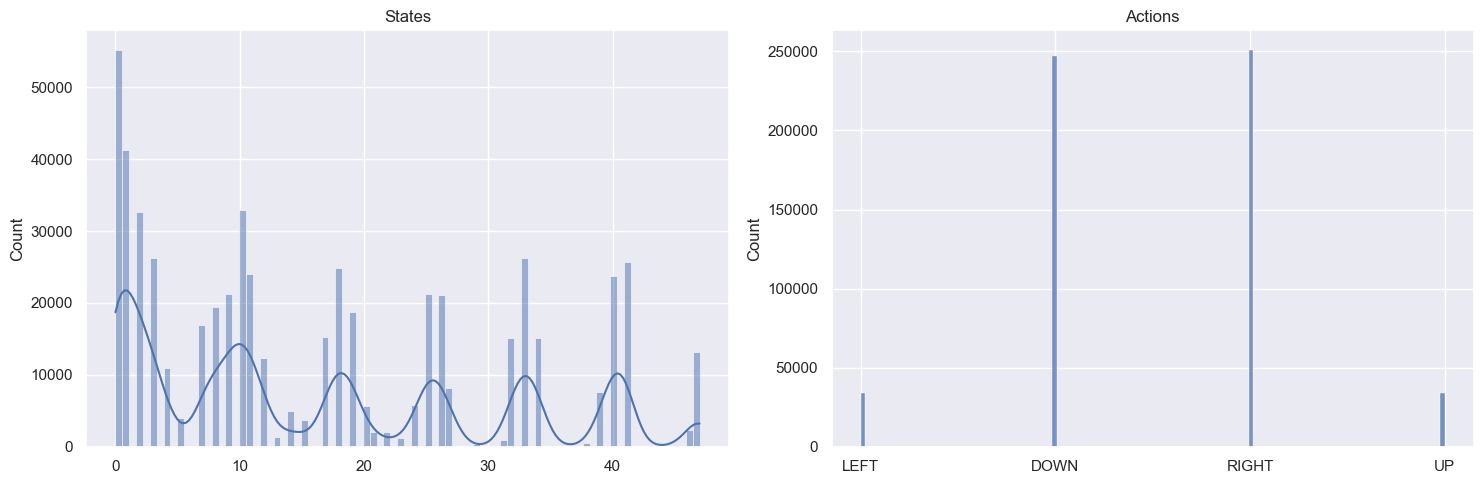

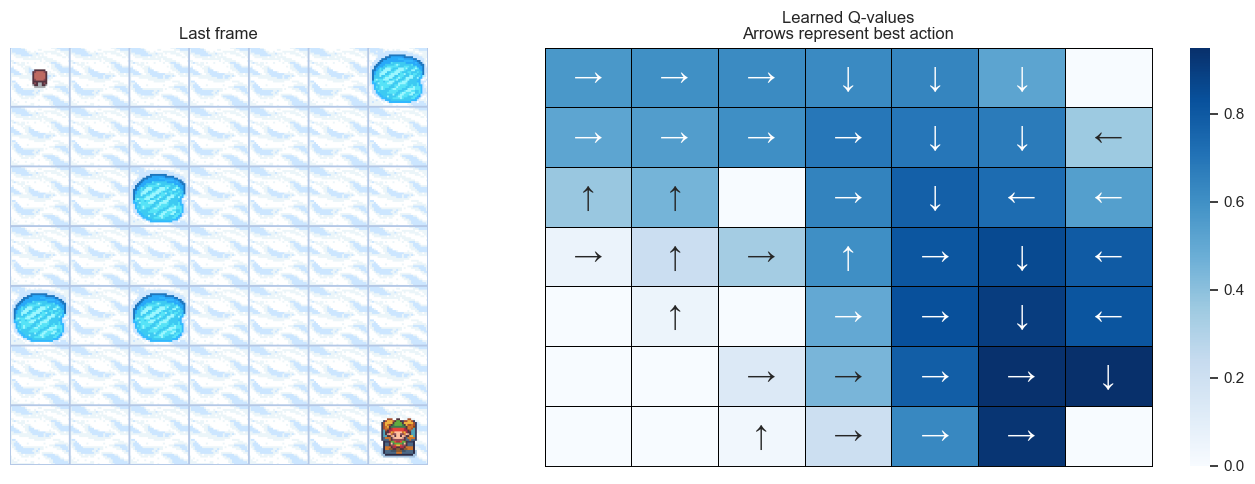

Map size: 9x9


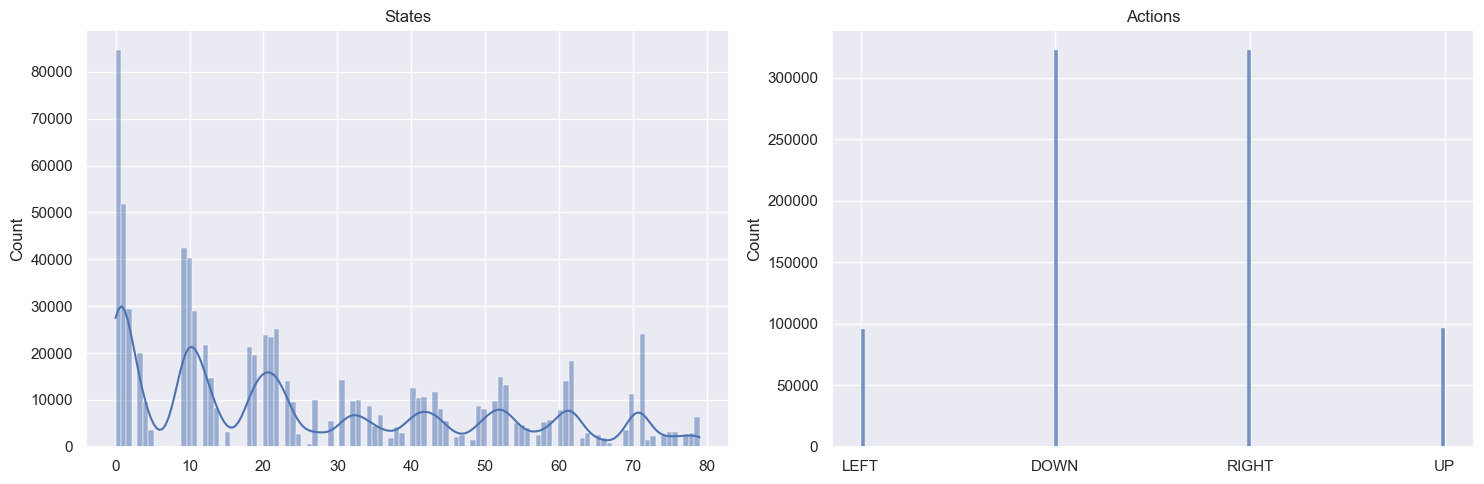

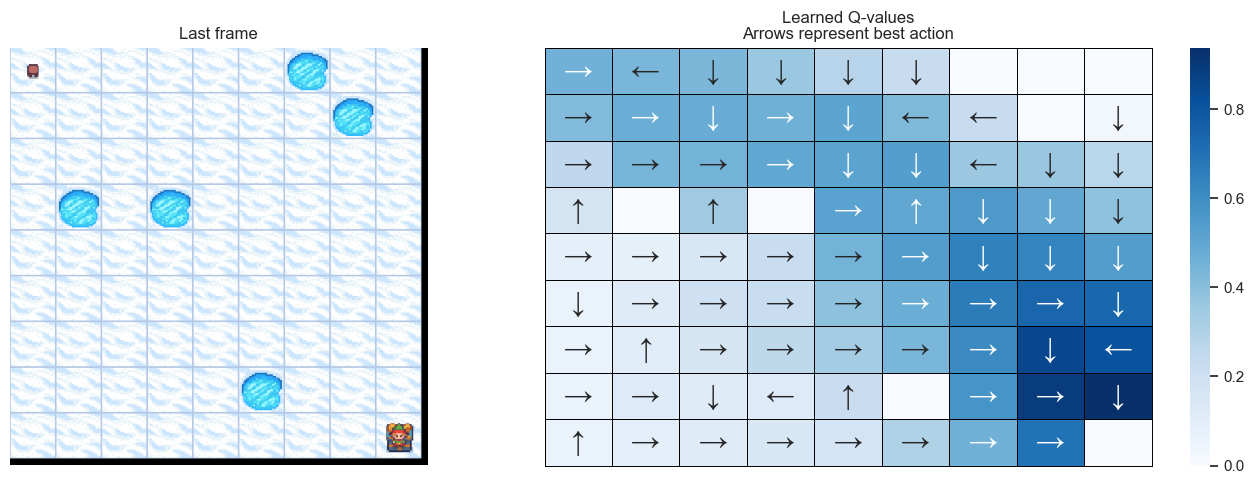

Map size: 11x11


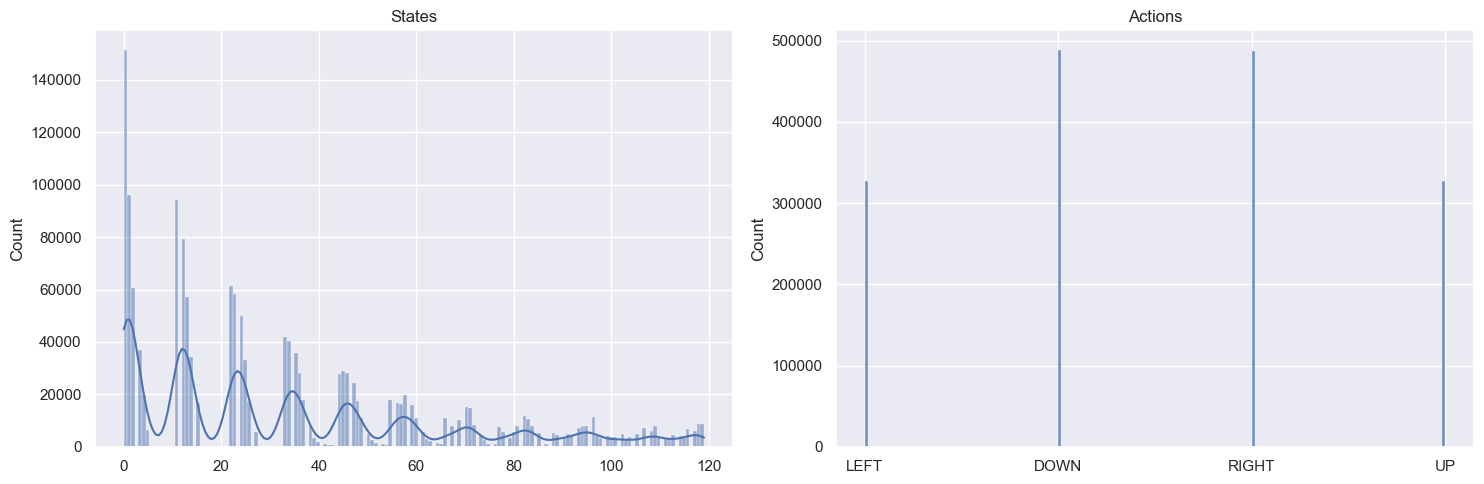

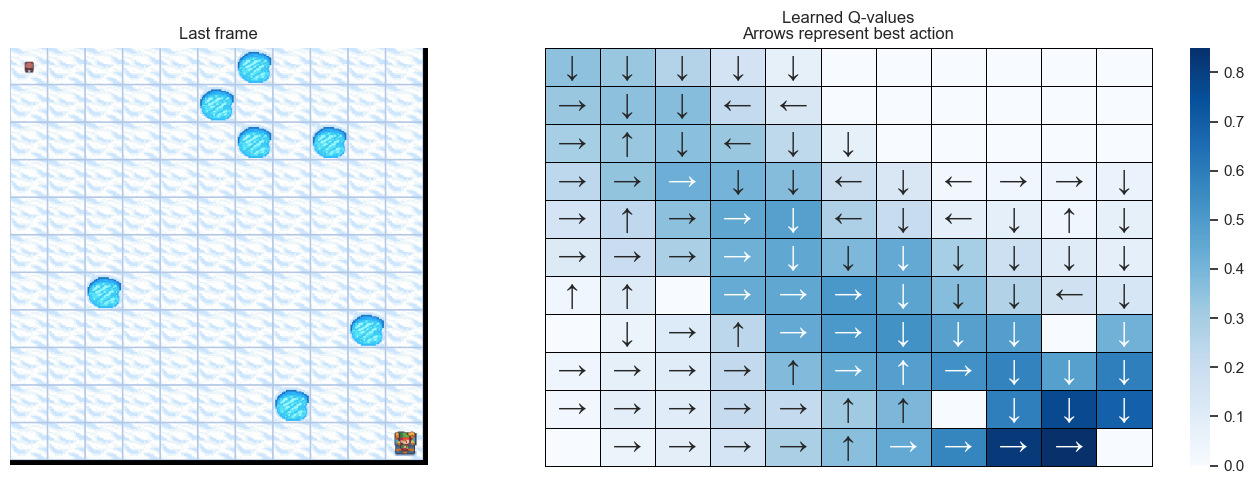

In [11]:
map_sizes = [4, 7, 9, 11]
res_all = pd.DataFrame()
st_all = pd.DataFrame()

for map_size in map_sizes:
    env = gym.make(
        "FrozenLake-v1",
        is_slippery=params.is_slippery,
        render_mode="rgb_array",
        desc=generate_random_map(
            size=map_size, p=params.proba_frozen, seed=params.seed
        ),
    )

    params = params._replace(
        action_size=env.action_space.n,
        state_size=env.observation_space.n,
        map_size=map_size,
    )
    env.action_space.seed(params.seed)

    learner = Qlearning(
        learning_rate=params.learning_rate,
        gamma=params.gamma,
        state_size=params.state_size,
        action_size=params.action_size,
    )
    explorer = EpsilonGreedy(epsilon=params.epsilon, rng=rng)

    print(f"Map size: {map_size}x{map_size}")
    rewards, steps, episodes, qtables, all_states, all_actions = run_env(
        env, params, learner, explorer
    )

    res, st = postprocess(episodes, params, rewards, steps, map_size)
    res_all = pd.concat([res_all, res])
    st_all = pd.concat([st_all, st])
    qtable = qtables.mean(axis=0)

    plot_states_actions_distribution(all_states, all_actions, map_size)
    plot_q_values_map(qtable, env, map_size)
    env.close()

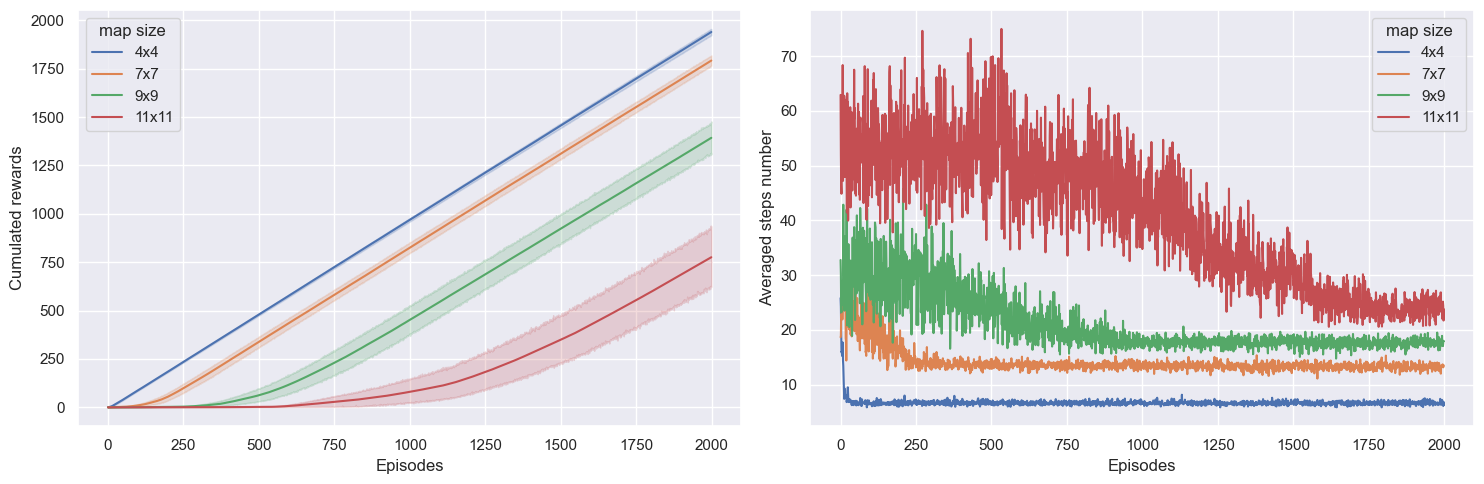

In [12]:
plot_steps_and_rewards(res_all, st_all)

**Observations:** The 4x4 map converges quickly, while larger maps (9x9, 11x11) need many more episodes for the reward signal to propagate back through the Q-table. The `DOWN` and `RIGHT` actions dominate since the agent starts top-left and the goal is bottom-right.

---

## Task 4: Hyperparameter Analysis

We now investigate how three key hyperparameters - learning rate ($\alpha$), discount factor ($\gamma$), and exploration rate ($\epsilon$) - affect Q-learning performance. For each sweep we fix the other two parameters and train on a **5x5** map.

### Helper function for sweeps

In [13]:
def sweep_hyperparameter(param_name, param_values, base_params, seed=123):
    """Run Q-learning for each value in param_values and return a combined dataframe."""
    all_res = pd.DataFrame()
    rng_sweep = np.random.default_rng(seed)

    for val in param_values:
        # Override the swept parameter
        p = base_params._replace(**{param_name: val})

        env = gym.make(
            "FrozenLake-v1",
            is_slippery=p.is_slippery,
            render_mode="rgb_array",
            desc=generate_random_map(size=p.map_size, p=p.proba_frozen, seed=p.seed),
        )
        p = p._replace(action_size=env.action_space.n, state_size=env.observation_space.n)
        env.action_space.seed(p.seed)

        learner = Qlearning(
            learning_rate=p.learning_rate,
            gamma=p.gamma,
            state_size=p.state_size,
            action_size=p.action_size,
        )
        explorer = EpsilonGreedy(epsilon=p.epsilon, rng=rng_sweep)

        rewards, steps, episodes, qtables, _, _ = run_env(env, p, learner, explorer)
        env.close()

        # Average cumulative rewards across runs
        cum_rewards = rewards.cumsum(axis=0).mean(axis=1)
        df = pd.DataFrame({
            "Episodes": episodes,
            "cum_rewards": cum_rewards,
            param_name: str(val),
        })
        all_res = pd.concat([all_res, df])

    return all_res


def plot_sweep(df, param_name, param_label):
    """Plot cumulative rewards for each hyperparameter value."""
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=df, x="Episodes", y="cum_rewards", hue=param_name, ax=ax)
    ax.set(ylabel="Cumulated rewards (avg over runs)", title=f"Effect of {param_label}")
    ax.legend(title=param_label)
    plt.tight_layout()
    plt.show()

In [14]:
# Base parameters for sweeps: 5x5 map, fixed defaults
base_params = Params(
    total_episodes=2000,
    learning_rate=0.8,
    gamma=0.95,
    epsilon=0.1,
    map_size=5,
    seed=123,
    is_slippery=False,
    n_runs=20,
    action_size=None,
    state_size=None,
    proba_frozen=0.9,
)

### 4.1 Sweep: Learning Rate ($\alpha$)

We fix $\gamma = 0.95$ and $\epsilon = 0.1$ and test $\alpha \in \{0.1, 0.3, 0.5, 0.8\}$.

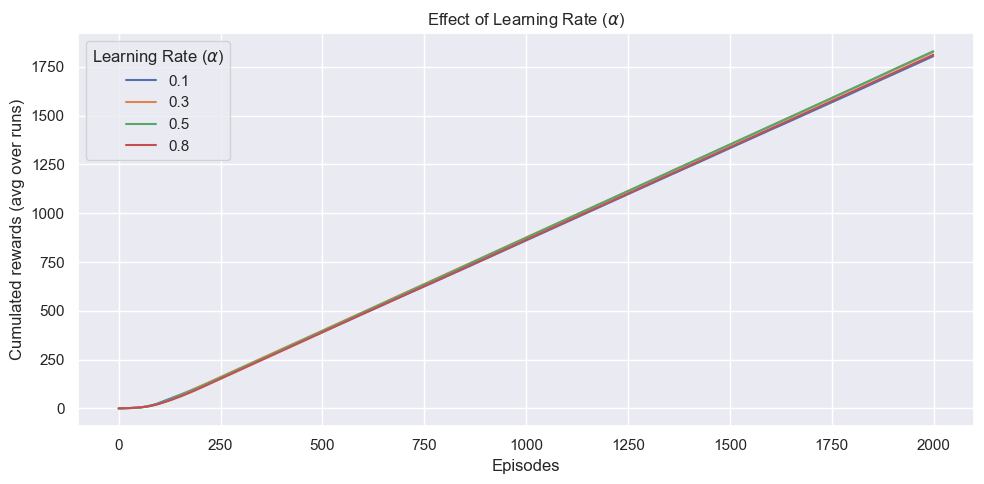

In [15]:
alpha_df = sweep_hyperparameter("learning_rate", [0.1, 0.3, 0.5, 0.8], base_params)
plot_sweep(alpha_df, "learning_rate", r"Learning Rate ($\alpha$)")

**Analysis - Learning Rate ($\alpha$):**

- A **low** learning rate (0.1) makes the agent very slow to incorporate new information, so cumulative rewards climb gradually. The Q-values barely change per update, requiring many more episodes to converge.
- A **high** learning rate (0.8) allows rapid convergence because the agent aggressively overwrites old estimates with new experience. In a deterministic environment like FrozenLake with `is_slippery=False`, this works well because there is no noise to overfit to.
- **Middle** values (0.3, 0.5) offer a balance. In stochastic environments, very high learning rates can cause instability because the agent overreacts to noisy transitions.

**Takeaway:** For deterministic FrozenLake, higher $\alpha$ converges faster. In stochastic settings, moderate values are safer.

### 4.2 Sweep: Discount Factor ($\gamma$)

We fix $\alpha = 0.8$ and $\epsilon = 0.1$ and test $\gamma \in \{0.5, 0.8, 0.95, 0.99\}$.

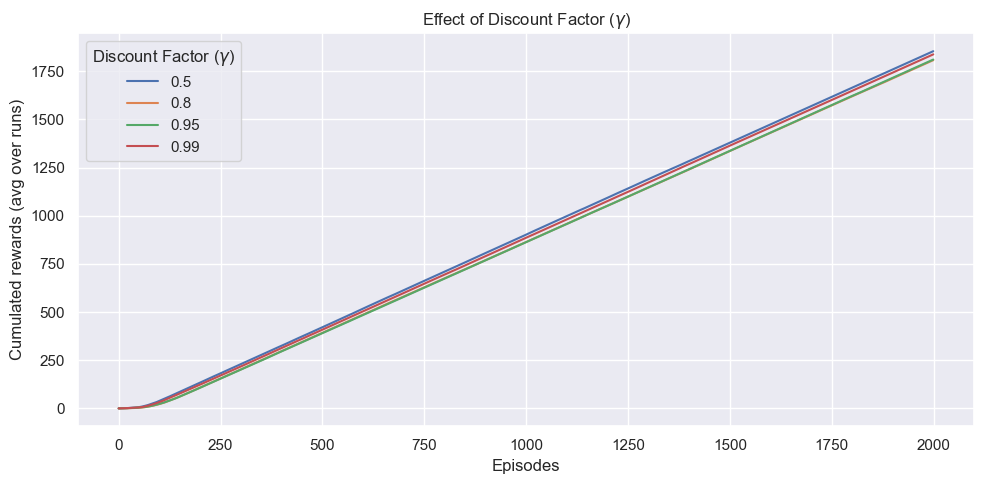

In [16]:
gamma_df = sweep_hyperparameter("gamma", [0.5, 0.8, 0.95, 0.99], base_params)
plot_sweep(gamma_df, "gamma", r"Discount Factor ($\gamma$)")

**Analysis - Discount Factor ($\gamma$):**

- A **low** discount factor ($\gamma = 0.5$) makes the agent myopic; it heavily discounts future rewards, so Q-values decay rapidly over multiple steps. On a 5x5 map, the goal is several steps away, and the reward signal may not propagate back to early states effectively.
- A **high** discount factor ($\gamma = 0.95$ or $0.99$) lets the agent plan further ahead by preserving the value of distant rewards. This is important in FrozenLake where the only reward (+1) comes at the very end.
- $\gamma$ close to 1 means the agent treats future rewards almost as valuable as immediate ones, encouraging it to find the shortest path to the goal.

**Takeaway:** In sparse-reward environments like FrozenLake, a high $\gamma$ (0.9+) is essential so the single terminal reward can propagate back through the Q-table to the starting state.

### 4.3 Sweep: Exploration Rate ($\epsilon$)

We fix $\alpha = 0.8$ and $\gamma = 0.95$ and test $\epsilon \in \{0.01, 0.1, 0.3, 0.5\}$.

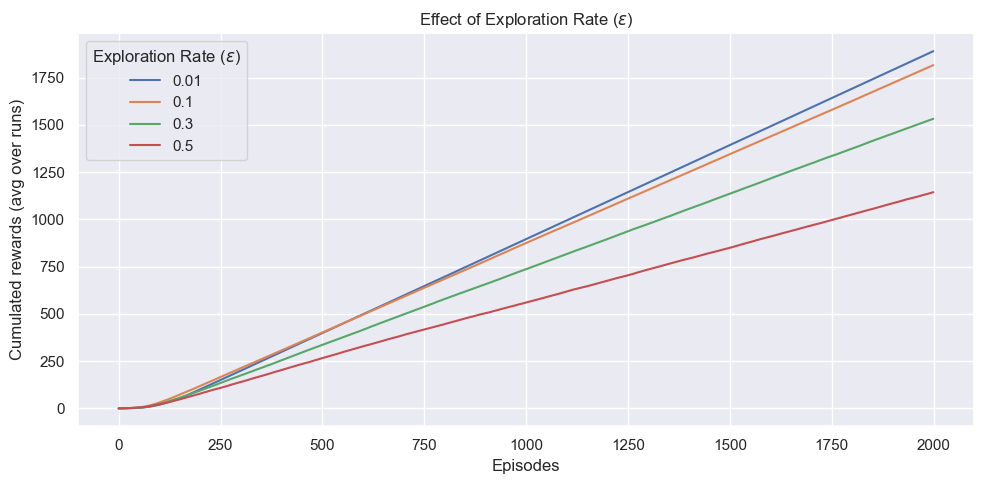

In [17]:
epsilon_df = sweep_hyperparameter("epsilon", [0.01, 0.1, 0.3, 0.5], base_params)
plot_sweep(epsilon_df, "epsilon", r"Exploration Rate ($\epsilon$)")

**Analysis - Exploration Rate ($\epsilon$):**

- A **very low** $\epsilon$ (0.01) means the agent almost always exploits. If it finds a path to the goal early, it converges quickly. However, it risks getting stuck if its initial Q-estimates are poor; it may never explore enough to discover the optimal path.
- A **moderate** $\epsilon$ (0.1) provides a good balance: the agent mostly exploits its learned Q-values but occasionally explores, allowing it to correct suboptimal policies.
- A **high** $\epsilon$ (0.5) means the agent takes random actions half the time. This hurts cumulative rewards because even after learning a good policy, it keeps deviating from it randomly. The agent explores thoroughly but never fully exploits what it has learned.

**Takeaway:** A small but nonzero $\epsilon$ (around 0.05-0.1) works best. In practice, decaying $\epsilon$ over time (high early exploration, low late exploitation) is the standard approach.

---

## Task 5: Policy Iteration

Policy Iteration is a **model-based** dynamic programming method. Unlike Q-learning which learns from sampled experience, Policy Iteration uses the full transition model $P(s' | s, a)$ to compute exact value functions.

It alternates between two steps:
1. **Policy Evaluation:** Compute $V^\pi(s)$ for the current policy $\pi$ by solving the Bellman equation.
2. **Policy Improvement:** Update the policy greedily with respect to the computed value function.

This repeats until the policy stabilizes.

### 5.1 Extract the Transition Model

In [18]:
# Create a fresh 5x5 environment for Policy Iteration
pi_map_size = 5
pi_env = gym.make(
    "FrozenLake-v1",
    is_slippery=False,
    render_mode="rgb_array",
    desc=generate_random_map(size=pi_map_size, p=0.9, seed=123),
)

n_states = pi_env.observation_space.n
n_actions = pi_env.action_space.n

# env.P is a dict: P[state][action] = list of (probability, next_state, reward, terminated)
# Let's inspect a few transitions
print(f"States: {n_states}, Actions: {n_actions}")
print(f"\nTransitions from state 0:")
for a in range(n_actions):
    print(f"  Action {a}: {pi_env.unwrapped.P[0][a]}")

States: 25, Actions: 4

Transitions from state 0:
  Action 0: [(1.0, 0, 0, False)]
  Action 1: [(1.0, 5, 0, False)]
  Action 2: [(1.0, 1, 0, False)]
  Action 3: [(1.0, 0, 0, False)]


### 5.2 Policy Iteration Implementation

In [19]:
def policy_evaluation(policy, P, n_states, n_actions, gamma=0.95, theta=1e-8):
    """
    Evaluate a policy by iteratively solving the Bellman expectation equation.
    
    Returns the value function V(s) for all states under the given policy.
    """
    V = np.zeros(n_states)

    while True:
        delta = 0
        for s in range(n_states):
            v = 0
            a = policy[s]
            for prob, next_state, reward, terminated in P[s][a]:
                v += prob * (reward + gamma * V[next_state] * (not terminated))
            delta = max(delta, abs(V[s] - v))
            V[s] = v
        if delta < theta:
            break

    return V


def policy_improvement(V, P, n_states, n_actions, gamma=0.95):
    """
    Improve the policy by acting greedily with respect to the value function.
    
    Returns the new policy and whether the policy changed.
    """
    new_policy = np.zeros(n_states, dtype=int)
    policy_stable = True

    for s in range(n_states):
        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, next_state, reward, terminated in P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_state] * (not terminated))
        new_policy[s] = np.argmax(q_values)

    return new_policy, q_values  # q_values from last state; we return full Q below


def policy_iteration(P, n_states, n_actions, gamma=0.95, max_iters=100):
    """
    Run Policy Iteration: alternate evaluation and improvement until convergence.
    """
    # Start with a random policy
    policy = np.zeros(n_states, dtype=int)
    
    for i in range(max_iters):
        # Evaluate
        V = policy_evaluation(policy, P, n_states, n_actions, gamma)
        
        # Improve
        old_policy = policy.copy()
        
        # Compute Q-values for all state-action pairs
        Q = np.zeros((n_states, n_actions))
        for s in range(n_states):
            for a in range(n_actions):
                for prob, next_state, reward, terminated in P[s][a]:
                    Q[s, a] += prob * (reward + gamma * V[next_state] * (not terminated))
        
        policy = np.argmax(Q, axis=1)
        
        if np.array_equal(policy, old_policy):
            print(f"Policy Iteration converged after {i + 1} iterations.")
            return policy, V, Q
    
    print(f"Policy Iteration did not converge within {max_iters} iterations.")
    return policy, V, Q

### 5.3 Run Policy Iteration

Policy Iteration converged after 9 iterations.


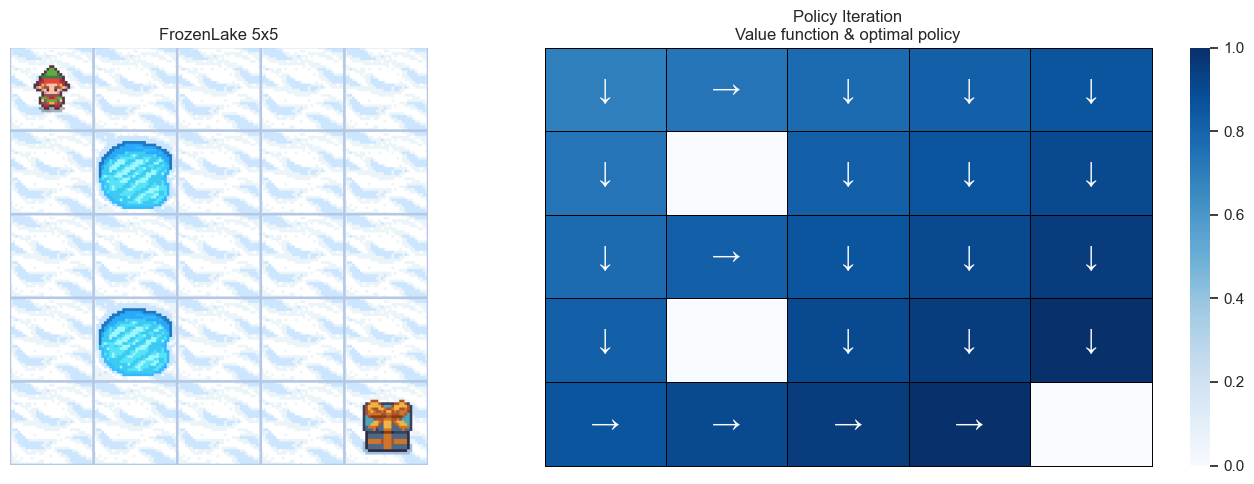

In [22]:
P = pi_env.unwrapped.P
pi_policy, pi_V, pi_Q = policy_iteration(P, n_states, n_actions, gamma=0.95)

# Visualize the Policy Iteration value function and policy
pi_val_max, pi_directions = qtable_directions_map(pi_Q, pi_map_size)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
pi_env.reset()
ax[0].imshow(pi_env.render())
ax[0].axis("off")
ax[0].set_title("FrozenLake 5x5")

sns.heatmap(
    pi_V.reshape(pi_map_size, pi_map_size),
    annot=pi_directions,
    fmt="",
    ax=ax[1],
    cmap=sns.color_palette("Blues", as_cmap=True),
    linewidths=0.7,
    linecolor="black",
    xticklabels=[],
    yticklabels=[],
    annot_kws={"fontsize": "xx-large"},
).set(title="Policy Iteration\nValue function & optimal policy")
for _, spine in ax[1].spines.items():
    spine.set_visible(True)
    spine.set_linewidth(0.7)
    spine.set_color("black")
plt.tight_layout()
plt.show()

### 5.4 Compare Q-Learning vs Policy Iteration

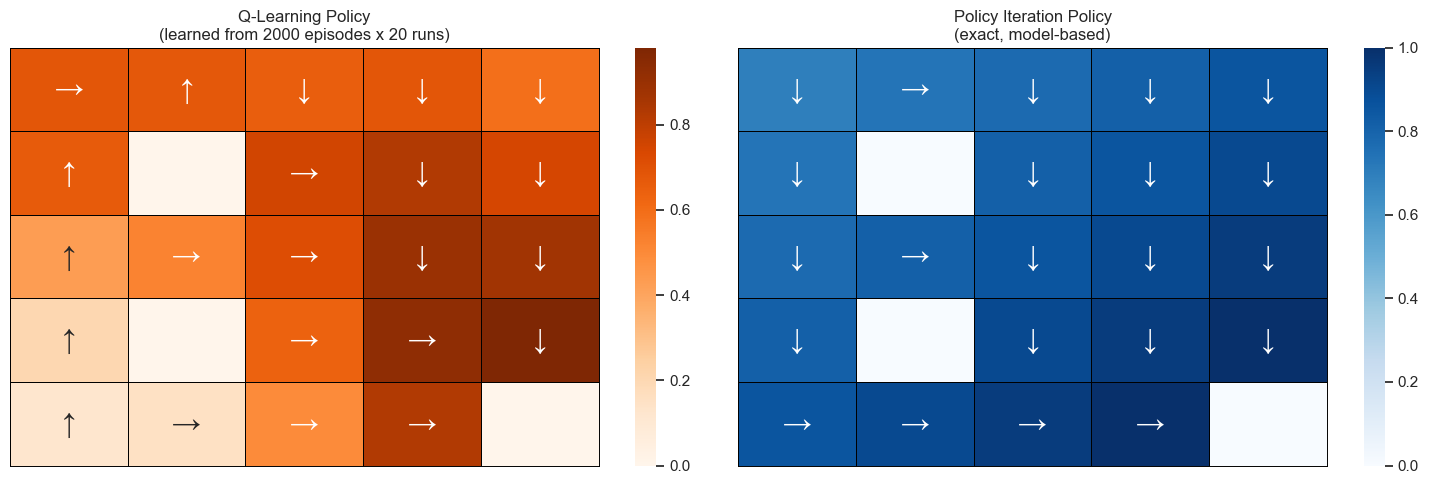

In [23]:
# Run Q-learning on the same 5x5 map for a fair comparison
ql_env = gym.make(
    "FrozenLake-v1",
    is_slippery=False,
    render_mode="rgb_array",
    desc=generate_random_map(size=pi_map_size, p=0.9, seed=123),
)

ql_params = Params(
    total_episodes=2000,
    learning_rate=0.8,
    gamma=0.95,
    epsilon=0.1,
    map_size=pi_map_size,
    seed=123,
    is_slippery=False,
    n_runs=20,
    action_size=ql_env.action_space.n,
    state_size=ql_env.observation_space.n,
    proba_frozen=0.9,
)
ql_env.action_space.seed(123)
ql_rng = np.random.default_rng(123)

ql_learner = Qlearning(
    learning_rate=ql_params.learning_rate,
    gamma=ql_params.gamma,
    state_size=ql_params.state_size,
    action_size=ql_params.action_size,
)
ql_explorer = EpsilonGreedy(epsilon=ql_params.epsilon, rng=ql_rng)

ql_rewards, ql_steps, ql_episodes, ql_qtables, _, _ = run_env(
    ql_env, ql_params, ql_learner, ql_explorer
)
ql_qtable = ql_qtables.mean(axis=0)

# Compare policies side by side
ql_val_max, ql_directions = qtable_directions_map(ql_qtable, pi_map_size)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(
    ql_val_max,
    annot=ql_directions, fmt="", ax=axes[0],
    cmap=sns.color_palette("Oranges", as_cmap=True),
    linewidths=0.7, linecolor="black",
    xticklabels=[], yticklabels=[],
    annot_kws={"fontsize": "xx-large"},
).set(title="Q-Learning Policy\n(learned from 2000 episodes x 20 runs)")

sns.heatmap(
    pi_V.reshape(pi_map_size, pi_map_size),
    annot=pi_directions, fmt="", ax=axes[1],
    cmap=sns.color_palette("Blues", as_cmap=True),
    linewidths=0.7, linecolor="black",
    xticklabels=[], yticklabels=[],
    annot_kws={"fontsize": "xx-large"},
).set(title="Policy Iteration Policy\n(exact, model-based)")

for ax in axes:
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

plt.tight_layout()
plt.show()
ql_env.close()

In [ ]:
# Quantitative comparison: do the policies agree?
ql_policy = np.argmax(ql_qtable, axis=1)
agreement = np.mean(ql_policy == pi_policy) * 100
print(f"Policy agreement: {agreement:.1f}% of states have the same action")

# Compare Q-values (normalize for fair comparison)
ql_q_normalized = ql_qtable / (ql_qtable.max() + 1e-10)
pi_q_normalized = pi_Q / (pi_Q.max() + 1e-10)
q_mse = np.mean((ql_q_normalized - pi_q_normalized) ** 2)
print(f"Normalized Q-value MSE: {q_mse:.6f}")

Policy agreement: 60.0% of states have the same action
Normalized Q-value MSE: 0.106978


: 

### 5.5 Discussion: Q-Learning vs Policy Iteration

| Aspect | Q-Learning | Policy Iteration |
|---|---|---|
| **Type** | Model-free | Model-based |
| **Requires transition model?** | No; learns from sampled (s, a, r, s') tuples | Yes - needs full $P(s' \| s, a)$ |
| **Convergence** | Asymptotic; needs many episodes, especially on larger maps | Exact; converges in very few iterations (typically 2-5 for FrozenLake) |
| **Optimality** | Converges to optimal Q* in the limit (with sufficient exploration and decaying $\alpha$) | Guaranteed optimal policy in finite iterations |
| **Scalability** | Works on any environment (just needs interaction) | Requires enumerating all states and actions; impractical for large/continuous spaces |
| **Computation** | Cost is per-episode interaction with the environment | Cost is per-sweep over the full state-action space |

**Key observations:**
- **Policy Iteration converges in just a few iterations** (typically 2-5), giving the provably optimal policy immediately. Q-learning needs thousands of episodes to approximate the same result.
- **Q-learning does not need the transition model**, making it applicable to environments where $P$ is unknown (e.g., real-world robotics, Atari games). Policy Iteration is limited to environments where we have the full model.
- On this small, deterministic FrozenLake, both methods should agree on the optimal policy. Any disagreement indicates Q-learning hasn't fully converged or that $\epsilon$-greedy exploration during evaluation introduces noise in the averaged Q-table.
- **In practice**, model-free methods like Q-learning (and its deep variant, DQN) are far more widely used because most interesting environments don't provide a transition model. Policy Iteration is valuable for understanding the theory and for small problems where the model is available.